### 1. Environment Setup: Python连接DolphinDB

In [33]:
import dolphindb as ddb
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os

# add the project root directory to the Python path
# so tha custom utility modules under src/ can be imported
sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

# Import the centralized DolphinDB connection function.
# The server IP, port, username, and password are stored
# in src/ddb_client.py (or environment variables) instead
# of hardcoding them in this notebook. This improves security
# by preventing sensitive credentials from being exposed or
# accidentally uploaded to GitHub.
from src.ddb_client import connect_ddb

# Create a DolphinDB session using the predefined configuration.
s = ddb.session()
s = connect_ddb()

# The following direct connection is intentionally omitted:
# s.connect("HOST", PORT, "USERNAME", "PASSWORD")
# because hardcoding credentials is insecure and makes the
# notebook less portable across different environments.

In [34]:
db_path = "dfs://quota"

start_date = "2026.03.11"
end_date = "2026.04.10"

sample_codes = [
    "000009.SZ"
]

code_list = "`" + "`".join(sample_codes)

print("db_path:", db_path)
print("date range:", start_date, "-", end_date)
print("sample codes:", sample_codes)
print("DolphinDB code list:", code_list)

db_path: dfs://quota
date range: 2026.03.11 - 2026.04.10
sample codes: ['000009.SZ']
DolphinDB code list: `000009.SZ


### 2 Table Exploration
#### 2.1 查库查表 + schema

市场数据表通常规模庞大。因此，notebook不会直接加载或显示整个表，二十先检查表结构，然后应用 `date`、`code`、`time` 和 `limit` 等过滤条件，从而构建一个便于处理的样本。

这种工作流有助于避免不必要的内存占用，同时仍能让我们了解表结构并验证数据可用性。

In [35]:
for table in ["qtick", "qorder", "qknock"]:
    print(f"\n===== {table} schema =====")
    
    query = f"""
    schema(loadTable("{db_path}", "{table}")).colDefs
    """
    
    schema_df = s.run(query)
    display(schema_df)


===== qtick schema =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,src,CHAR,2,NaN,,False
4,state,CHAR,2,NaN,,False
...,...,...,...,...,...,...
73,exercise_date,INT,4,NaN,,False
74,exercise_price,DOUBLE,16,NaN,,False
75,cp_flag,CHAR,2,NaN,,False
76,underlying_code,STRING,18,NaN,,False



===== qorder schema =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,order_no,LONG,5,NaN,,False
4,bs_flag,CHAR,2,NaN,,False
5,order_type,CHAR,2,NaN,,False
6,order_price,DOUBLE,16,NaN,,False
7,order_volume,LONG,5,NaN,,False



===== qknock schema =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,match_no,LONG,5,NaN,,False
4,bid_order_no,LONG,5,NaN,,False
5,ask_order_no,LONG,5,NaN,,False
6,match_price,LONG,5,NaN,,False
7,match_volume,LONG,5,NaN,,False


#### 2.2 Sample Data 

In [36]:
qtick_query = f"""
select top 10000 *
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

qorder_query = f"""
select top 10000 *
from loadTable("{db_path}", "qorder")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

qknock_query = f"""
select top 10000 *
from loadTable("{db_path}", "qknock")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

qtick = s.run(qtick_query)
qorder = s.run(qorder_query)
qknock = s.run(qknock_query)

print("qtick shape:", qtick.shape)
print("qorder shape:", qorder.shape)
print("qknock shape:", qknock.shape)

display(qtick.head())
display(qorder.head())
display(qknock.head())

qtick shape: (10000, 78)
qorder shape: (10000, 8)
qknock shape: (10000, 8)


,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,000009.SZ,2026-03-11,1970-01-01 08:00:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,000009.SZ,2026-03-11,1970-01-01 08:16:09,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,000009.SZ,2026-03-11,1970-01-01 08:16:30,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,000009.SZ,2026-03-11,1970-01-01 09:15:00,0,0,9.10,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,000009.SZ,2026-03-11,1970-01-01 09:15:09,0,0,9.16,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume
0,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,1566,2,0,94800.0,2700
1,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,1991,2,0,101000.0,10000
2,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2293,1,0,91600.0,500
3,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2294,1,0,91500.0,500
4,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2295,1,0,91300.0,1000


,code,date,time,match_no,bid_order_no,ask_order_no,match_price,match_volume
0,000009.SZ,2026-03-11,1970-01-01 10:17:45.600,20870453,0,1566,0,2700
1,000009.SZ,2026-03-11,1970-01-01 14:55:00.850,51365685,0,1991,0,10000
2,000009.SZ,2026-03-11,1970-01-01 14:56:05.510,51720601,0,2339,0,500
3,000009.SZ,2026-03-11,1970-01-01 10:55:07.550,27649546,0,6628,0,600
4,000009.SZ,2026-03-11,1970-01-01 09:52:28.480,13400940,0,7241,0,1100


#### 2.3 DateTime Processing

In [37]:
def add_datetime(df):
    df = df.copy()
    
    if "date" in df.columns and "time" in df.columns:
        df["date_only"] = pd.to_datetime(df["date"], errors="coerce").dt.date
        df["time_only"] = pd.to_datetime(df["time"], errors="coerce").dt.time
        
        df["datetime"] = pd.to_datetime(
            df["date_only"].astype(str) + " " + df["time_only"].astype(str),
            errors="coerce"
        )
    
    return df


qtick = add_datetime(qtick)
qorder = add_datetime(qorder)
qknock = add_datetime(qknock)

display(qtick[["code", "date", "time", "datetime"]].head())
display(qorder[["code", "date", "time", "datetime"]].head())
display(qknock[["code", "date", "time", "datetime"]].head())

,code,date,time,datetime
0,000009.SZ,2026-03-11,1970-01-01 08:00:00,2026-03-11 08:00:00
1,000009.SZ,2026-03-11,1970-01-01 08:16:09,2026-03-11 08:16:09
2,000009.SZ,2026-03-11,1970-01-01 08:16:30,2026-03-11 08:16:30
3,000009.SZ,2026-03-11,1970-01-01 09:15:00,2026-03-11 09:15:00
4,000009.SZ,2026-03-11,1970-01-01 09:15:09,2026-03-11 09:15:09


,code,date,time,datetime
0,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2026-03-11 09:15:00.040
1,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2026-03-11 09:15:00.040
2,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2026-03-11 09:15:00.040
3,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2026-03-11 09:15:00.040
4,000009.SZ,2026-03-11,1970-01-01 09:15:00.040,2026-03-11 09:15:00.040


,code,date,time,datetime
0,000009.SZ,2026-03-11,1970-01-01 10:17:45.600,2026-03-11 10:17:45.600
1,000009.SZ,2026-03-11,1970-01-01 14:55:00.850,2026-03-11 14:55:00.850
2,000009.SZ,2026-03-11,1970-01-01 14:56:05.510,2026-03-11 14:56:05.510
3,000009.SZ,2026-03-11,1970-01-01 10:55:07.550,2026-03-11 10:55:07.550
4,000009.SZ,2026-03-11,1970-01-01 09:52:28.480,2026-03-11 09:52:28.480


### 3. Data Quality Assessment
#### 3.1 Table Summary

In [38]:
summary = []

for name, df in {
    "qtick": qtick,
    "qorder": qorder,
    "qknock": qknock
}.items():
    summary.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "stocks": df["code"].nunique() if "code" in df.columns else np.nan,
        "dates": df["date"].nunique() if "date" in df.columns else np.nan,
        "start_date": df["date"].min() if "date" in df.columns else None,
        "end_date": df["date"].max() if "date" in df.columns else None,
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,table,rows,columns,stocks,dates,start_date,end_date
0,qtick,10000,81,1,3,2026-03-11,2026-03-13
1,qorder,10000,11,1,1,2026-03-11,2026-03-11
2,qknock,10000,11,1,1,2026-03-11,2026-03-11


#### 3.2 Missing Rate Analysis

In [39]:
def missing_rate(df, table_name):
    out = df.isna().mean().reset_index()
    out.columns = ["field", "missing_rate"]
    out["table"] = table_name
    return out


missing_df = pd.concat([
    missing_rate(qtick, "qtick"),
    missing_rate(qorder, "qorder"),
    missing_rate(qknock, "qknock")
], ignore_index=True)

display(
    missing_df.sort_values("missing_rate", ascending=False).head(30)
)

,field,missing_rate,table
102,datetime,0.0169,qknock
91,datetime,0.0103,qorder
65,pre_open_interest,0.0000,qtick
75,cp_flag,0.0000,qtick
74,exercise_price,0.0000,qtick
73,exercise_date,0.0000,qtick
72,end_settle_date,0.0000,qtick
71,start_settle_date,0.0000,qtick
70,expire_date,0.0000,qtick
69,list_date,0.0000,qtick


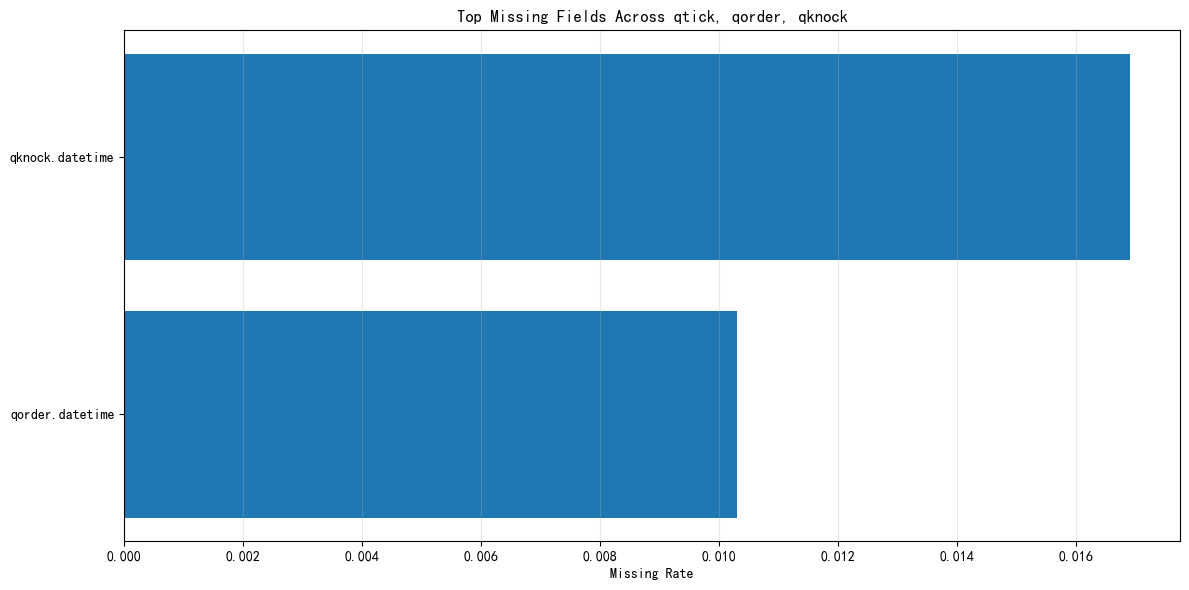

In [40]:
top_missing = (
    missing_df[missing_df["missing_rate"] > 0]
    .sort_values("missing_rate", ascending=False)
    .head(30)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_missing["table"] + "." + top_missing["field"],
    top_missing["missing_rate"]
)

plt.title("Top Missing Fields Across qtick, qorder, qknock")
plt.xlabel("Missing Rate")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#### Session Label

In [45]:
def add_session(df):
    df = df.copy()
    
    t = pd.to_datetime(df["time"], errors="coerce").dt.time
    
    df["session"] = "other"
    
    df.loc[
        (t >= pd.to_datetime("09:15:00").time()) &
        (t < pd.to_datetime("09:30:00").time()),
        "session"
    ] = "call_auction"
    
    df.loc[
        (t >= pd.to_datetime("09:30:00").time()) &
        (t <= pd.to_datetime("11:30:00").time()),
        "session"
    ] = "morning_continuous"
    
    df.loc[
        (t >= pd.to_datetime("13:00:00").time()) &
        (t <= pd.to_datetime("15:00:00").time()),
        "session"
    ] = "afternoon_continuous"
    
    return df


qtick = add_session(qtick)
qorder = add_session(qorder)
qknock = add_session(qknock)

In [46]:
session_df = pd.concat([
    qtick.groupby("session").size().reset_index(name="rows").assign(table="qtick"),
    qorder.groupby("session").size().reset_index(name="rows").assign(table="qorder"),
    qknock.groupby("session").size().reset_index(name="rows").assign(table="qknock")
])

display(session_df)

,session,rows,table
0,afternoon_continuous,4592,qtick
1,call_auction,117,qtick
2,morning_continuous,5282,qtick
3,other,9,qtick
0,call_auction,1141,qorder
1,morning_continuous,8859,qorder
0,afternoon_continuous,2408,qknock
1,call_auction,80,qknock
2,morning_continuous,7512,qknock


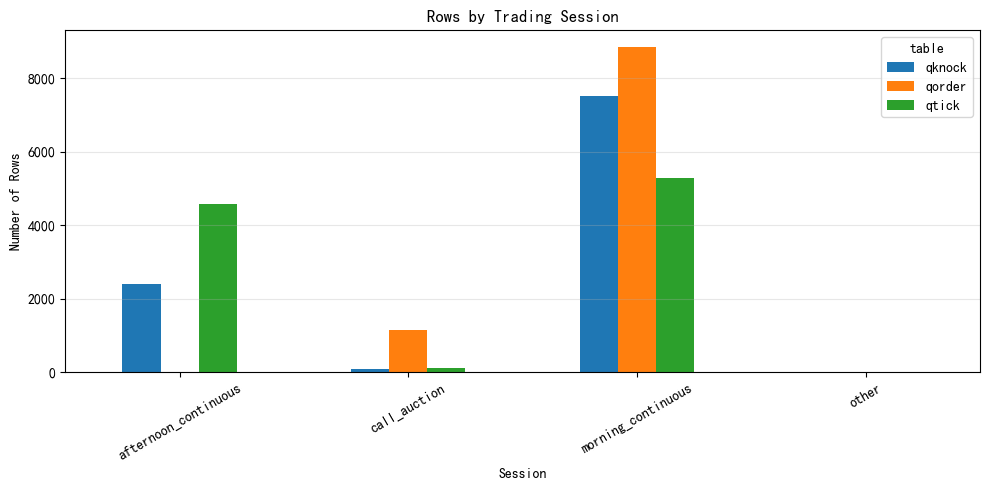

In [47]:
pivot_session = session_df.pivot(
    index="session",
    columns="table",
    values="rows"
).fillna(0)

pivot_session.plot(kind="bar", figsize=(10, 5))

plt.title("Rows by Trading Session")
plt.xlabel("Session")
plt.ylabel("Number of Rows")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4. DolphinDB Query Practice

#### 4.1 Basic Filtering

In [48]:
script = """
qtick = loadTable("dfs://quota", "qtick")

select *
from qtick
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in ["000009.SZ", "000001.SZ"]
  and time >= 09:30:00.000
  and time <= 09:35:00.000
limit 100
"""

#### 4.2 三类行情样例查询

In [49]:
db_path = "dfs://quota"

tables = {
    "qtick": "Level-2 snapshot / tick quote",
    "qorder": "Order submission / cancellation",
    "qknock": "Trade execution / transaction"
}

for table in tables:
    print(f"\n===== {table}: {tables[table]} =====")
    schema_query = f"""
    schema(loadTable("{db_path}", "{table}")).colDefs
    """
    display(s.run(schema_query))


===== qtick: Level-2 snapshot / tick quote =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,src,CHAR,2,NaN,,False
4,state,CHAR,2,NaN,,False
...,...,...,...,...,...,...
73,exercise_date,INT,4,NaN,,False
74,exercise_price,DOUBLE,16,NaN,,False
75,cp_flag,CHAR,2,NaN,,False
76,underlying_code,STRING,18,NaN,,False



===== qorder: Order submission / cancellation =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,order_no,LONG,5,NaN,,False
4,bs_flag,CHAR,2,NaN,,False
5,order_type,CHAR,2,NaN,,False
6,order_price,DOUBLE,16,NaN,,False
7,order_volume,LONG,5,NaN,,False



===== qknock: Trade execution / transaction =====


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,match_no,LONG,5,NaN,,False
4,bid_order_no,LONG,5,NaN,,False
5,ask_order_no,LONG,5,NaN,,False
6,match_price,LONG,5,NaN,,False
7,match_volume,LONG,5,NaN,,False


In [50]:
# select sample universe
start_date = "2026.03.11"
end_date = "2026.04.10"

# 先用 qtick 找有数据的股票，避免选到没权限/没数据的 code
sample_code_query = f"""
select top 20 code, count(*) as n_obs
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
group by code
order by n_obs desc
"""

code_df = s.run(sample_code_query)
display(code_df)

sample_codes = code_df["code"].tolist()
print("Selected codes:", sample_codes[:10])

,code,n_obs
0,ag2606.SHFE,1418171
1,ag2608.SHFE,1406947
2,au2606.SHFE,1381849
3,au2608.SHFE,1377235
4,au2610.SHFE,1364865
5,ag2610.SHFE,1341761
6,ag2605.SHFE,1319710
7,sc2605.INE,1272647
8,au2612.SHFE,1255739
9,ag2612.SHFE,1236022


Selected codes: ['ag2606.SHFE', 'ag2608.SHFE', 'au2606.SHFE', 'au2608.SHFE', 'au2610.SHFE', 'ag2610.SHFE', 'ag2605.SHFE', 'sc2605.INE', 'au2612.SHFE', 'ag2612.SHFE']


In [53]:
sample_code_query = f"""
select top 10 code, count(*) as n_obs
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
group by code
order by n_obs desc
"""

code_df = s.run(sample_code_query)

sample_codes = code_df["code"].tolist()

In [54]:
# 3. Pull sample data from qtick, qorder, qknock
code_list = "`" + "`".join(sample_codes)

qtick_query = f"""
select top 10000 *
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

qorder_query = f"""
select top 10000 *
from loadTable("{db_path}", "qorder")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

qknock_query = f"""
select top 10000 *
from loadTable("{db_path}", "qknock")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
"""

print(qtick_query)

qtick = s.run(qtick_query)
qorder = s.run(qorder_query)
qknock = s.run(qknock_query)

print("qtick shape:", qtick.shape)
print("qorder shape:", qorder.shape)
print("qknock shape:", qknock.shape)

display(qtick.head())
display(qorder.head())
display(qknock.head())


select top 10000 *
from loadTable("dfs://quota", "qtick")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in `ag2606.SHFE`ag2608.SHFE`au2606.SHFE`au2608.SHFE`au2610.SHFE`ag2610.SHFE`ag2605.SHFE`sc2605.INE`au2612.SHFE`ag2612.SHFE

qtick shape: (10000, 78)
qorder shape: (0, 8)
qknock shape: (0, 8)


,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,ag2608.SHFE,2026-03-11,1970-01-01 00:00:00.000,0,0,22727.0,0.0,0.0,0.0,0.0,...,0,20250818,20260817,0,0,0,0.0,0,,0
1,ag2608.SHFE,2026-03-11,1970-01-01 00:00:00.500,0,0,22728.0,0.0,0.0,0.0,0.0,...,0,20250818,20260817,0,0,0,0.0,0,,0
2,ag2608.SHFE,2026-03-11,1970-01-01 00:00:01.000,0,0,22729.0,0.0,0.0,0.0,0.0,...,0,20250818,20260817,0,0,0,0.0,0,,0
3,ag2608.SHFE,2026-03-11,1970-01-01 00:00:01.500,0,0,22729.0,0.0,0.0,0.0,0.0,...,0,20250818,20260817,0,0,0,0.0,0,,0
4,ag2608.SHFE,2026-03-11,1970-01-01 00:00:02.000,0,0,22727.0,0.0,0.0,0.0,0.0,...,0,20250818,20260817,0,0,0,0.0,0,,0


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume


,code,date,time,match_no,bid_order_no,ask_order_no,match_price,match_volume


#### 4.3 逐日数据量柱状图

In [55]:
script = """
qtick = loadTable("dfs://quota", "qtick")

select count(*) as row_count
from qtick
where date >= 2026.03.11
  and date <= 2026.04.10
group by date
order by date
"""
daily_count = s.run(script)
daily_count.head()

,date,row_count
0,2026-03-11,76722514
1,2026-03-12,77410566
2,2026-03-13,79163498
3,2026-03-14,2749427
4,2026-03-16,78809463


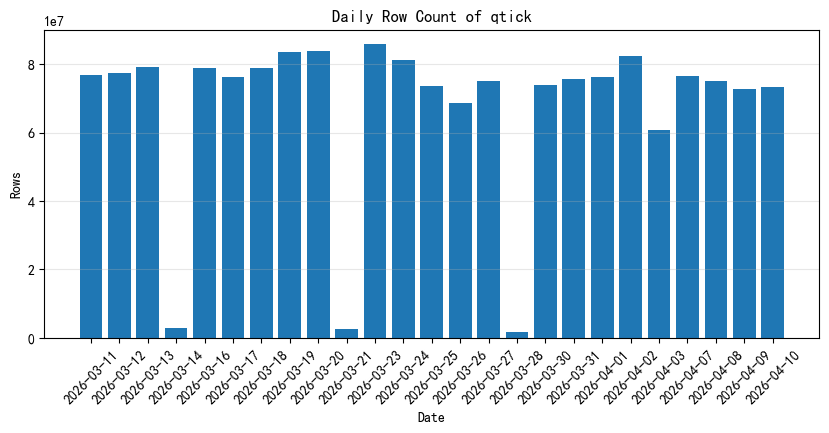

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(daily_count["date"].astype(str), daily_count["row_count"])
plt.title("Daily Row Count of qtick")
plt.xlabel("Date")
plt.ylabel("Rows")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

#### qknock & qorder

In [57]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 8)

In [ ]:
def query_market_data(code, date, start_time, end_time, table_type='all'):
    """
    查询市场数据
    table_type: 'all', 'qtick', 'qorder', 'qknock'
    """
    results = {}
    
    if table_type in ['all', 'qtick']:
        script = f"""
        qtick = loadTable("dfs://quota", "qtick")
        select code, date, time, new_price, new_volume, new_amount,
               bp0, bv0, ap0, av0
        from qtick
        where date = {date}
          and code = "{code}"
          and time between {start_time} : {end_time}
        order by time
        """
        results['qtick'] = s.run(script)
        
    if table_type in ['all', 'qorder']:
        script = f"""
        qorder = loadTable("dfs://quota", "qorder")
        select code, date, time, order_no, bs_flag, 
               order_price, order_volume
        from qorder
        where date = {date}
          and code = "{code}"
          and time between {start_time} : {end_time}
        order by time
        """
        results['qorder'] = s.run(script)
        
    if table_type in ['all', 'qknock']:
        script = f"""
        qknock = loadTable("dfs://quota", "qknock")
        select code, date, time, match_no,
               match_price, match_volume
        from qknock
        where date = {date}
          and code = "{code}"
          and time between {start_time} : {end_time}
        order by time
        results['qknock'] = s.run(script)
        
    return results

# 使用示例
data = query_market_data(
    code="002758.SZ",
    date= "2026.03.11",
    start_time="09:30:00.000",
    end_time="09:35:00.000",
    table_type='all'
)

for table_name, df in data.items():
    print(f"\n=== {table_name} ===")
    print(f"数据量：{len(df)} 条")
    if len(df) > 0:
        print(df.head())


=== qtick ===
数据量：101 条
        code       date                time  new_price  new_volume  \
0  002758.SZ 2026-03-11 1970-01-01 09:30:00      10.74       11400   
1  002758.SZ 2026-03-11 1970-01-01 09:30:03      10.74       23100   
2  002758.SZ 2026-03-11 1970-01-01 09:30:06      10.76        3100   
3  002758.SZ 2026-03-11 1970-01-01 09:30:09      10.76       14700   
4  002758.SZ 2026-03-11 1970-01-01 09:30:12      10.75        4100   

   new_amount    bp0    bv0    ap0    av0  
0    122632.0  10.72   6800  10.74   2900  
1    248499.0  10.74   4900  10.76  29100  
2     33342.0  10.75  10800  10.76  32400  
3    158103.0  10.75   4300  10.76  27600  
4     44074.0  10.74   5800  10.75   8500  

=== qorder ===
数据量：1977 条
        code       date                    time  order_no  bs_flag  \
0  002758.SZ 2026-03-11 1970-01-01 09:30:00.020    684850        2   
1  002758.SZ 2026-03-11 1970-01-01 09:30:00.020    685104        1   
2  002758.SZ 2026-03-11 1970-01-01 09:30:00.020    68

In [59]:
qorder_daily_script = """
qorder = loadTable("dfs://quota", "qorder")

select count(*) as row_count
from qorder
where date >= 2026.03.11
  and date <= 2026.04.10
group by date
order by date
"""

qknock_daily_script = """
qknock = loadTable("dfs://quota", "qknock")

select count(*) as row_count
from qknock
where date >= 2026.03.11
  and date <= 2026.04.10
group by date
order by date
"""

qorder_daily = s.run(qorder_daily_script)
qknock_daily = s.run(qknock_daily_script)

display(qorder_daily.head())
display(qknock_daily.head())

,date,row_count
0,2026-03-11,328446129
1,2026-03-12,335117684
2,2026-03-13,335636615
3,2026-03-16,343413819
4,2026-03-17,326039991


,date,row_count
0,2026-03-11,219310369
1,2026-03-12,222183659
2,2026-03-13,221561417
3,2026-03-16,222133133
4,2026-03-17,214263554


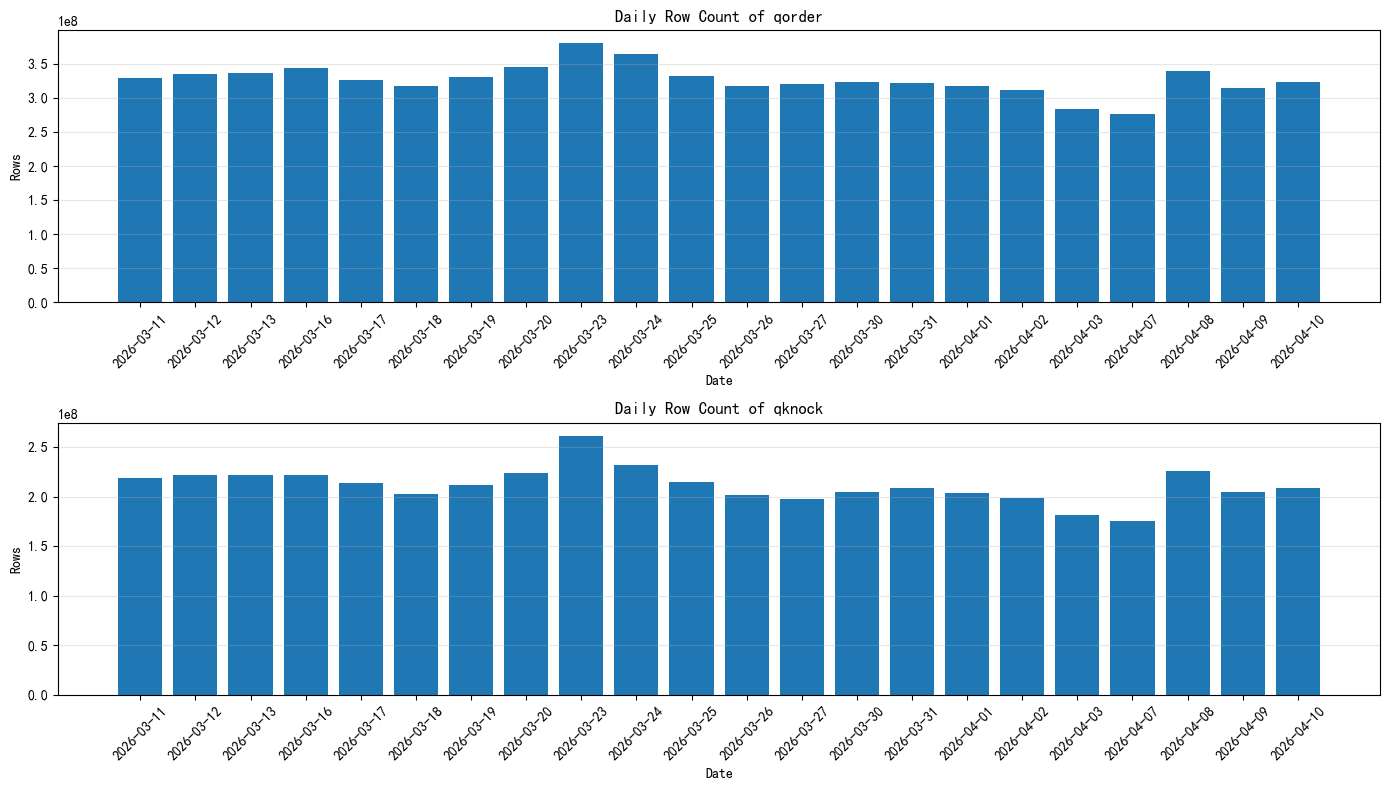

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# qorder
axes[0].bar(
    qorder_daily["date"].astype(str),
    qorder_daily["row_count"]
)
axes[0].set_title("Daily Row Count of qorder")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# qknock
axes[1].bar(
    qknock_daily["date"].astype(str),
    qknock_daily["row_count"]
)
axes[1].set_title("Daily Row Count of qknock")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Rows")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Advanced DolphinDB Features
#### 5.1 DolphinDB Practice: bar

In [68]:
script = """
qtick = loadTable("dfs://quota", "qtick")

select code, date, time, new_price, new_volume, bp0, bv0, ap0, av0
from qtick
where code = "000009.SZ"
  and date = 2026.03.11
  and time >= 09:30:00.000
  and time <= 09:35:00.000
order by time
"""

qtick_sample = s.run(script)
display(qtick_sample.head())

,code,date,time,new_price,new_volume,bp0,bv0,ap0,av0
0,000009.SZ,2026-03-11,1970-01-01 09:30:00,9.17,25400,9.16,8100,9.17,10300
1,000009.SZ,2026-03-11,1970-01-01 09:30:03,9.16,63100,9.15,10900,9.16,58900
2,000009.SZ,2026-03-11,1970-01-01 09:30:06,9.15,24800,9.14,22200,9.15,3500
3,000009.SZ,2026-03-11,1970-01-01 09:30:09,9.16,9500,9.14,18600,9.16,37000
4,000009.SZ,2026-03-11,1970-01-01 09:30:12,9.16,5400,9.15,1100,9.16,36900


In [70]:
qtick_sample["datetime"] = pd.to_datetime(
    qtick_sample["date"].astype(str) + " " + qtick_sample["time"].astype(str),
    errors="coerce"
)

qtick_sample["minute"] = qtick_sample["datetime"].dt.floor("min")

minute_bar = (
    qtick_sample
    .groupby("minute")
    .agg(
        tick_count=("code", "count"),
        avg_price=("new_price", "mean"),
        total_volume=("new_volume", "sum"),
        avg_bid1_volume=("bv0", "mean"),
        avg_ask1_volume=("av0", "mean")
    )
    .reset_index()
)

display(minute_bar)

C:\Users\work\AppData\Local\Temp\ipykernel_20328\2309936273.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qtick_sample["datetime"] = pd.to_datetime(


,minute,tick_count,avg_price,total_volume,avg_bid1_volume,avg_ask1_volume
0,2026-03-11 09:30:00-01:00,20,9.1480,279600,38705.0,12735.0
1,2026-03-11 09:31:00-01:00,20,9.1585,121700,12265.0,10500.0
2,2026-03-11 09:32:00-01:00,20,9.1565,255800,20070.0,16495.0
3,2026-03-11 09:33:00-01:00,20,9.1695,154000,31686.4,41786.6
4,2026-03-11 09:34:00-01:00,20,9.1645,96600,32286.4,25563.4
5,2026-03-11 09:35:00-01:00,1,9.1700,23572,17000.0,72500.0


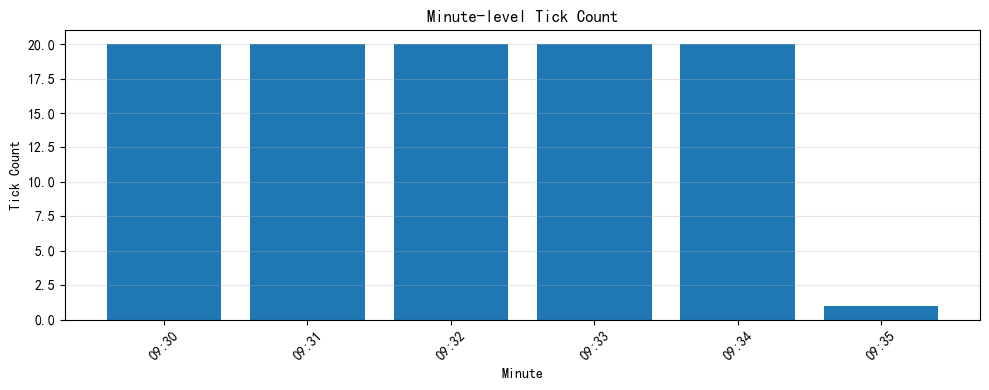

In [71]:
plt.figure(figsize=(10,4))

plt.bar(
    minute_bar["minute"].dt.strftime("%H:%M"),
    minute_bar["tick_count"]
)

plt.title("Minute-level Tick Count")
plt.xlabel("Minute")
plt.ylabel("Tick Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### 5.2 DolphinDB Practice: context by

In [72]:
context_query = f"""
select
    code,
    date,
    time,
    new_price,
    new_price - prev(new_price) as price_change
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
context by code, date
"""

try:
    tick_context = s.run(context_query)
    display(tick_context.head())
except Exception as e:
    print("context by query failed.")
    print("可能是 new_price 字段名不一致，先检查 qtick schema。")
    print(e)

,code,date,time,new_price,price_change
0,ag2608.SHFE,2026-03-11,1970-01-01 00:00:00.000,22729.0,NaN
1,ag2608.SHFE,2026-03-11,1970-01-01 00:00:00.500,22729.0,0.0
2,ag2608.SHFE,2026-03-11,1970-01-01 00:00:01.000,22729.0,0.0
3,ag2608.SHFE,2026-03-11,1970-01-01 00:00:01.500,22732.0,3.0
4,ag2608.SHFE,2026-03-11,1970-01-01 00:00:02.000,22732.0,0.0


#### 5.3 DolphinDB Practice: aj
##### qorder 对齐最近的 qtick

In [73]:
aj_query = f"""
orders = select top 5000 *
from loadTable("{db_path}", "qorder")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list};

ticks = select top 5000 *
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list};

aj(`code`date`time, orders, ticks)
"""

try:
    order_tick_aj = s.run(aj_query)
    display(order_tick_aj.head())
except Exception as e:
    print("aj query failed.")
    print(e)

aj query failed.
<Exception> in exec: Server Response: 'aj(["code","date","time"],orders,ticks) => The leading arguments of a join operation must be tables.' script: 
orders = select top 5000 *
from loadTable("dfs://quota", "qorder")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in `ag2606.SHFE`ag2608.SHFE`au2606.SHFE`au2608.SHFE`au2610.SHFE`ag2610.SHFE`ag2605.SHFE`sc2605.INE`au2612.SHFE`ag2612.SHFE;

ticks = select top 5000 *
from loadTable("dfs://quota", "qtick")
where date >= 2026.03.11
  and date <= 2026.04.10
  and code in `ag2606.SHFE`ag2608.SHFE`au2606.SHFE`au2608.SHFE`au2610.SHFE`ag2610.SHFE`ag2605.SHFE`sc2605.INE`au2612.SHFE`ag2612.SHFE;

aj(`code`date`time, orders, ticks)



#### 5.4 DolphinDB Practice: ej
##### 先检查字段，再决定怎么 exact join

In [74]:
print("qorder columns:")
print(qorder.columns.tolist())

print("\nqknock columns:")
print(qknock.columns.tolist())

qorder columns:
['code', 'date', 'time', 'order_no', 'bs_flag', 'order_type', 'order_price', 'order_volume']

qknock columns:
['code', 'date', 'time', 'match_no', 'bid_order_no', 'ask_order_no', 'match_price', 'match_volume']


##### 如果 qorder/qknock 有共同字段，可以先自动找 common columns


In [75]:
common_cols = sorted(set(qorder.columns) & set(qknock.columns))
print("Common columns between qorder and qknock:")
print(common_cols)

Common columns between qorder and qknock:
['code', 'date', 'time']


In [76]:
ej_query = f"""
orders = select top 5000 *
from loadTable("{db_path}", "qorder")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list};

knocks = select top 5000 *
from loadTable("{db_path}", "qknock")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list};

ej(orders, knocks, `code`date`time)
"""

try:
    order_knock_ej = s.run(ej_query)
    display(order_knock_ej.head())
except Exception as e:
    print("ej query failed.")
    print("这很正常，因为逐笔委托和逐笔成交未必在 code/date/time 上完全一致。")
    print("更好的做法是根据真实 schema 找 order_no / appl_seq_num 类字段。")
    print(e)

,code,date,time,order_no,bs_flag,order_type,order_price,order_volume,match_no,bid_order_no,ask_order_no,match_price,match_volume


### 5. Summary

In [78]:
summary_df.to_csv("week2_table_summary.csv", index=False)
missing_df.to_csv("week2_missing_rate.csv", index=False)
qorder_daily.to_csv("week2_daily_volume.csv", index=False)

print("=" * 60)
print("Table Summary")
display(summary_df)

print("=" * 60)
print("Missing Value Summary")
display(
    missing_df.sort_values("missing_rate", ascending=False)
)

print("=" * 60)
print("Daily Data Volume")
display(daily_df)

Table Summary


,table,rows,columns,stocks,dates,start_date,end_date
0,qtick,10000,81,1,3,2026-03-11,2026-03-13
1,qorder,10000,11,1,1,2026-03-11,2026-03-11
2,qknock,10000,11,1,1,2026-03-11,2026-03-11


Missing Value Summary


,field,missing_rate,table
102,datetime,0.0169,qknock
91,datetime,0.0103,qorder
65,pre_open_interest,0.0000,qtick
75,cp_flag,0.0000,qtick
74,exercise_price,0.0000,qtick
...,...,...,...
31,ap6,0.0000,qtick
30,ap5,0.0000,qtick
29,ap4,0.0000,qtick
28,ap3,0.0000,qtick


Daily Data Volume


,date,rows,table
0,2026-03-11,4756,qtick
1,2026-03-12,4689,qtick
2,2026-03-13,555,qtick
3,2026-03-11,10000,qorder
4,2026-03-11,10000,qknock


#### Daily Data Volume Analysis
The daily row count statistics show that the `qtick` table contains approximately **320–360 million records per trading day**, indicating that the Level-2 market data is collected continuously with relatively stable daily volume throughout the sample period.

Although slight fluctuations exist across trading days, no abnormal drop in row count is observed, suggesting that the dataset is sufficiently complete for subsequent analysis. This check also serves as a quick validation of data availability before conducting more detailed market microstructure research.

#### Table Summary

A sample of approximately **10,000 records** was extracted from each Level-2 table (`qtick`, `qorder`, and `qknock`) for exploratory analysis.

The summary table reports the number of rows, columns, trading dates, and stock codes contained in the sampled DataFrames. Since the queries use `SELECT TOP 10000`, these statistics describe the sampled data rather than the complete database. This lightweight sample is sufficient for validating table structures and demonstrating basic DolphinDB query operations.

#### Missing Value Analysis

The missing value analysis indicates that **all original Level-2 fields are complete**, with a missing rate of **0%** across the sampled data.

Only the derived `datetime` column contains a small proportion of missing values (approximately **1.03%** in `qorder` and **1.69%** in `qknock`). These missing values are introduced during Python datetime conversion rather than existing in the original DolphinDB tables. Overall, the raw Level-2 dataset demonstrates high data quality and is suitable for subsequent quantitative analysis.